# Periodontal Survey Analysis Report

This notebook presents a research-style exploratory analysis of the periodontal survey among IT professionals. The augmented `plus_generated` dataset is used for primary visuals and exploratory inference, while the observed-only dataset is loaded again for sensitivity checks.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, SVG, display

def find_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'periodontal_survey_mar_8_cutoff.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')

ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from analysis.run_analysis import run_pipeline

AUGMENTED_CSV = ROOT / 'periodontal_survey_mar_8_cutoff_plus_generated.csv'
OBSERVED_CSV = ROOT / 'periodontal_survey_mar_8_cutoff.csv'
OUT_DIR = ROOT / 'outputs'
TABLES_DIR = OUT_DIR / 'tables'
FIGURES_DIR = OUT_DIR / 'figures'
FORCE_REGENERATE = False

required_outputs = [
    OUT_DIR / 'cleaned_analysis_dataset.csv',
    TABLES_DIR / 'analysis_metadata.json',
    TABLES_DIR / 'insights.md',
]

if FORCE_REGENERATE or not all(path.exists() for path in required_outputs):
    run_pipeline(AUGMENTED_CSV, OBSERVED_CSV, OUT_DIR)


## Data provenance

The notebook reconstructs the score variables directly from item responses. This is necessary because the source app writes a `Knowledge Score` field but does not actually compute it.

In [2]:
metadata = json.loads((TABLES_DIR / 'analysis_metadata.json').read_text())
metadata

{'observed_rows': 101,
 'generated_rows': 150,
 'total_rows': 251,
 'observed_last_timestamp': '2026-03-06T18:49:07.555000+00:00',
 'augmented_last_timestamp': '2026-03-12T00:01:13.428000+00:00',
 'duration_artifact_rows': 10,
 'major_localities': ['Bangalore',
  'Bellandur',
  'Chennai',
  'Hsr Layout',
  'Hyderabad',
  'JP Nagar',
  'Madurai',
  'Nagercoil',
  'Ulsoor',
  'Whitefield'],
 'group_variables': ['age_range',
  'gender',
  'professional_experience',
  'work_mode',
  'previous_treatment',
  'sample_source']}

## Analysis-ready dataset

The cleaned dataset adds `sample_source`, recomputed score columns, response labels, locality normalization, and a duration artifact flag.

In [3]:
analysis_df = pd.read_csv(OUT_DIR / 'cleaned_analysis_dataset.csv', parse_dates=['timestamp'])
analysis_df[['sample_source', 'age_range', 'gender', 'professional_experience', 'work_mode', 'previous_treatment', 'knowledge_score', 'attitude_score', 'practice_index']].head()

,sample_source,age_range,gender,professional_experience,work_mode,previous_treatment,knowledge_score,attitude_score,practice_index
0,observed,20-30 years,Female,0-3 years,Full time,Yes,10,33,24
1,observed,30-40 years,Male,6-10 years,Hybrid,No,7,21,22
2,observed,20-30 years,Female,3-6 years,Full time,No,8,27,23
3,observed,20-30 years,Female,3-6 years,Full time,No,6,29,14
4,observed,20-30 years,Female,3-6 years,Hybrid,No,10,22,28


## Descriptive tables

In [4]:
table_one = pd.read_csv(TABLES_DIR / 'table_1_sample_characteristics.csv')
composite_summary = pd.read_csv(TABLES_DIR / 'composite_score_summary.csv')
reliability_summary = pd.read_csv(TABLES_DIR / 'reliability_summary.csv')
display(table_one.head(20))
display(composite_summary)
display(reliability_summary)

,section,variable,level,overall,observed,generated
0,Demographics,Age range,20-30 years,155 (61.8%),62 (61.4%),93 (62.0%)
1,Demographics,Age range,30-40 years,77 (30.7%),31 (30.7%),46 (30.7%)
2,Demographics,Age range,40-50 years,14 (5.6%),6 (5.9%),8 (5.3%)
3,Demographics,Age range,50-60 years,5 (2.0%),2 (2.0%),3 (2.0%)
4,Demographics,Gender,Male,170 (67.7%),68 (67.3%),102 (68.0%)
5,Demographics,Gender,Female,79 (31.5%),32 (31.7%),47 (31.3%)
6,Demographics,Gender,Prefer not to say,2 (0.8%),1 (1.0%),1 (0.7%)
7,Demographics,Gender,Other,0 (0.0%),0 (0.0%),0 (0.0%)
8,Demographics,Professional experience,0-3 years,81 (32.3%),30 (29.7%),51 (34.0%)
9,Demographics,Professional experience,3-6 years,67 (26.7%),27 (26.7%),40 (26.7%)


,metric,dataset,n,mean,sd,median,q1,q3,minimum,maximum
0,knowledge_score,overall,251,6.363,2.356,6.0,4.00,8.0,1,10
1,knowledge_score,observed,101,6.208,2.487,6.0,4.00,8.0,1,10
2,knowledge_score,generated,150,6.467,2.266,7.0,4.25,8.0,1,10
3,attitude_score,overall,251,27.267,4.644,28.0,24.00,30.0,16,38
4,attitude_score,observed,101,27.109,4.935,28.0,24.00,30.0,16,38
5,attitude_score,generated,150,27.373,4.450,27.5,25.00,30.0,16,38
6,practice_index,overall,251,20.940,4.266,22.0,17.00,24.0,9,30
7,practice_index,observed,101,20.891,4.465,22.0,17.00,25.0,10,30
8,practice_index,generated,150,20.973,4.142,22.5,17.25,24.0,9,28


,dataset,scale,alpha,note
0,augmented,knowledge,0.7013,Binary correctness scale.
1,augmented,attitude,0.7506,Likert scale with A5 and A8 reverse-coded.
2,augmented,practice_index,0.5430,Behavior index quality check only; not treated...
3,observed,knowledge,0.7358,Binary correctness scale.
4,observed,attitude,0.7825,Likert scale with A5 and A8 reverse-coded.
5,observed,practice_index,0.5806,Behavior index quality check only; not treated...


## Statistical analysis outputs

In [5]:
subgroup_results = pd.read_csv(TABLES_DIR / 'subgroup_results_augmented.csv')
pairwise_results = pd.read_csv(TABLES_DIR / 'subgroup_pairwise_results_augmented.csv')
kap_correlations = pd.read_csv(TABLES_DIR / 'kap_correlations.csv')
regression_results = pd.read_csv(TABLES_DIR / 'regression_results.csv')
sensitivity_summary = pd.read_csv(TABLES_DIR / 'sensitivity_summary.csv')
display(subgroup_results.head(15))
display(kap_correlations)
display(regression_results.head(15))
display(sensitivity_summary.head(15))

,dataset,outcome,group_var,test_type,levels,n_total,group_sizes,group_means,group_medians,statistic,p_value,effect_size,effect_size_name,direction
0,augmented,knowledge_score,age_range,Kruskal-Wallis,"20-30 years, 30-40 years, 40-50 years, 50-60 y...",251,20-30 years=155; 30-40 years=77; 40-50 years=1...,20-30 years=6.32; 30-40 years=6.51; 40-50 year...,20-30 years=6.00; 30-40 years=7.00; 40-50 year...,0.407346,9.387209e-01,0.000000,epsilon-squared,Omnibus
1,augmented,knowledge_score,gender,Kruskal-Wallis,"Male, Female, Prefer not to say",251,Male=170; Female=79; Prefer not to say=2,Male=5.73; Female=7.65; Prefer not to say=9.50,Male=6.00; Female=8.00; Prefer not to say=9.50,40.494629,1.609545e-09,0.155220,epsilon-squared,Omnibus
2,augmented,knowledge_score,professional_experience,Kruskal-Wallis,"0-3 years, 3-6 years, 6-10 years, 10-15 years,...",251,0-3 years=81; 3-6 years=67; 6-10 years=45; 10-...,0-3 years=6.43; 3-6 years=6.51; 6-10 years=6.0...,0-3 years=7.00; 3-6 years=7.00; 6-10 years=6.0...,8.864942,6.456538e-02,0.019776,epsilon-squared,Omnibus
3,augmented,knowledge_score,work_mode,Kruskal-Wallis,"Full time, Hybrid, Work from home (Remote)",251,Full time=196; Hybrid=37; Work from home (Remo...,Full time=6.29; Hybrid=7.05; Work from home (R...,Full time=6.00; Hybrid=8.00; Work from home (R...,4.974867,8.312304e-02,0.011995,epsilon-squared,Omnibus
4,augmented,knowledge_score,previous_treatment,Mann-Whitney U,No vs Yes,251,No=199; Yes=52,No=6.44; Yes=6.06,No=7.00; Yes=6.00,5752.500000,2.114869e-01,0.111809,Cliff's delta,No > Yes
5,augmented,knowledge_score,sample_source,Mann-Whitney U,observed vs generated,251,observed=101; generated=150,observed=6.21; generated=6.47,observed=6.00; generated=7.00,7148.500000,4.466039e-01,-0.056304,Cliff's delta,generated > observed
6,augmented,attitude_score,age_range,Kruskal-Wallis,"20-30 years, 30-40 years, 40-50 years, 50-60 y...",251,20-30 years=155; 30-40 years=77; 40-50 years=1...,20-30 years=27.98; 30-40 years=25.97; 40-50 ye...,20-30 years=28.00; 30-40 years=26.00; 40-50 ye...,7.364621,6.114088e-02,0.017671,epsilon-squared,Omnibus
7,augmented,attitude_score,gender,Kruskal-Wallis,"Male, Female, Prefer not to say",251,Male=170; Female=79; Prefer not to say=2,Male=26.71; Female=28.41; Prefer not to say=30.00,Male=27.00; Female=28.00; Prefer not to say=30.00,5.757712,5.619901e-02,0.015152,epsilon-squared,Omnibus
8,augmented,attitude_score,professional_experience,Kruskal-Wallis,"0-3 years, 3-6 years, 6-10 years, 10-15 years,...",251,0-3 years=81; 3-6 years=67; 6-10 years=45; 10-...,0-3 years=27.74; 3-6 years=27.87; 6-10 years=2...,0-3 years=27.00; 3-6 years=28.00; 6-10 years=2...,3.337987,5.029362e-01,0.000000,epsilon-squared,Omnibus
9,augmented,attitude_score,work_mode,Kruskal-Wallis,"Full time, Hybrid, Work from home (Remote)",251,Full time=196; Hybrid=37; Work from home (Remo...,Full time=26.81; Hybrid=28.65; Work from home ...,Full time=27.00; Hybrid=29.00; Work from home ...,11.732983,2.832795e-03,0.039246,epsilon-squared,Omnibus


,dataset,pair,left_metric,right_metric,rho,p_value,ci_low,ci_high,n
0,augmented,knowledge_score__attitude_score,knowledge_score,attitude_score,0.315310,3.374444e-07,0.203539,0.416792,251
1,augmented,knowledge_score__practice_index,knowledge_score,practice_index,0.381173,4.206155e-10,0.264315,0.490838,251
2,augmented,attitude_score__practice_index,attitude_score,practice_index,0.239439,1.279529e-04,0.124407,0.348240,251
3,observed,knowledge_score__attitude_score,knowledge_score,attitude_score,0.362932,1.914470e-04,0.187945,0.530723,101
4,observed,knowledge_score__practice_index,knowledge_score,practice_index,0.459957,1.304835e-06,0.282840,0.608736,101
5,observed,attitude_score__practice_index,attitude_score,practice_index,0.199975,4.496232e-02,0.000414,0.383320,101


,dataset,model,outcome,term,term_label,coef,std_err,t_value,p_value,ci_low,ci_high
0,augmented,knowledge_model,knowledge_score,Intercept,Intercept,5.379533e+00,3.376427e-01,15.932621,3.762502e-57,4.717765e+00,6.041300e+00
1,augmented,knowledge_model,knowledge_score,"C(age_range, Treatment(reference='20-30 years'...",Age Range: 30-40 years vs 20-30 years,4.405761e-02,4.475171e-01,0.098449,9.215758e-01,-8.330598e-01,9.211750e-01
2,augmented,knowledge_model,knowledge_score,"C(age_range, Treatment(reference='20-30 years'...",Age Range: 40-50 years vs 20-30 years,1.496672e+00,7.342911e-01,2.038254,4.152452e-02,5.748781e-02,2.935856e+00
3,augmented,knowledge_model,knowledge_score,"C(age_range, Treatment(reference='20-30 years'...",Age Range: 50-60 years vs 20-30 years,2.816000e+00,8.875257e-01,3.172866,1.509423e-03,1.076481e+00,4.555518e+00
4,augmented,knowledge_model,knowledge_score,"C(gender, Treatment(reference='Male'))[T.Female]",Gender: Female vs Male,2.111211e+00,2.996225e-01,7.046237,1.838204e-12,1.523962e+00,2.698460e+00
5,augmented,knowledge_model,knowledge_score,"C(gender, Treatment(reference='Male'))[T.Prefe...",Gender: Prefer not to say vs Male,3.836720e+00,1.281832e+00,2.993155,2.761097e-03,1.324377e+00,6.349064e+00
6,augmented,knowledge_model,knowledge_score,"C(gender, Treatment(reference='Male'))[T.Other]",Gender: Other vs Male,-4.912528e-16,3.851418e-16,-1.275511,2.021283e-01,-1.246117e-15,2.636113e-16
7,augmented,knowledge_model,knowledge_score,"C(professional_experience, Treatment(reference...",Professional Experience: 3-6 years vs 0-3 years,2.239537e-01,3.771112e-01,0.593866,5.526015e-01,-5.151707e-01,9.630780e-01
8,augmented,knowledge_model,knowledge_score,"C(professional_experience, Treatment(reference...",Professional Experience: 6-10 years vs 0-3 years,-3.505586e-01,4.505568e-01,-0.778056,4.365358e-01,-1.233634e+00,5.325165e-01
9,augmented,knowledge_model,knowledge_score,"C(professional_experience, Treatment(reference...",Professional Experience: 10-15 years vs 0-3 years,1.264145e+00,5.995594e-01,2.108457,3.499145e-02,8.903058e-02,2.439260e+00


,comparison_type,subject,augmented_value,observed_value,direction_changed,note
0,regression_term,knowledge_model | Age Range: 30-40 years vs 20...,4.405761e-02,4.281820e-01,False,Coefficient direction was stable.
1,regression_term,knowledge_model | Age Range: 40-50 years vs 20...,1.496672e+00,3.809748e-02,False,Coefficient direction was stable.
2,regression_term,knowledge_model | Age Range: 50-60 years vs 20...,2.816000e+00,1.978720e+00,False,Coefficient direction was stable.
3,regression_term,knowledge_model | Gender: Female vs Male,2.111211e+00,2.198482e+00,False,Coefficient direction was stable.
4,regression_term,knowledge_model | Gender: Prefer not to say vs...,3.836720e+00,5.364796e+00,False,Coefficient direction was stable.
5,regression_term,knowledge_model | Gender: Other vs Male,-4.912528e-16,1.779484e-14,True,Sign changed between augmented and observed-on...
6,regression_term,knowledge_model | Professional Experience: 3-6...,2.239537e-01,1.434504e-04,False,Coefficient direction was stable.
7,regression_term,knowledge_model | Professional Experience: 6-1...,-3.505586e-01,-8.432181e-01,False,Coefficient direction was stable.
8,regression_term,knowledge_model | Professional Experience: 10-...,1.264145e+00,-7.028981e-02,True,Sign changed between augmented and observed-on...
9,regression_term,knowledge_model | Professional Experience: 15+...,-1.728078e+00,-1.441575e+00,False,Coefficient direction was stable.


## Figures

### Demographic Profile Panel

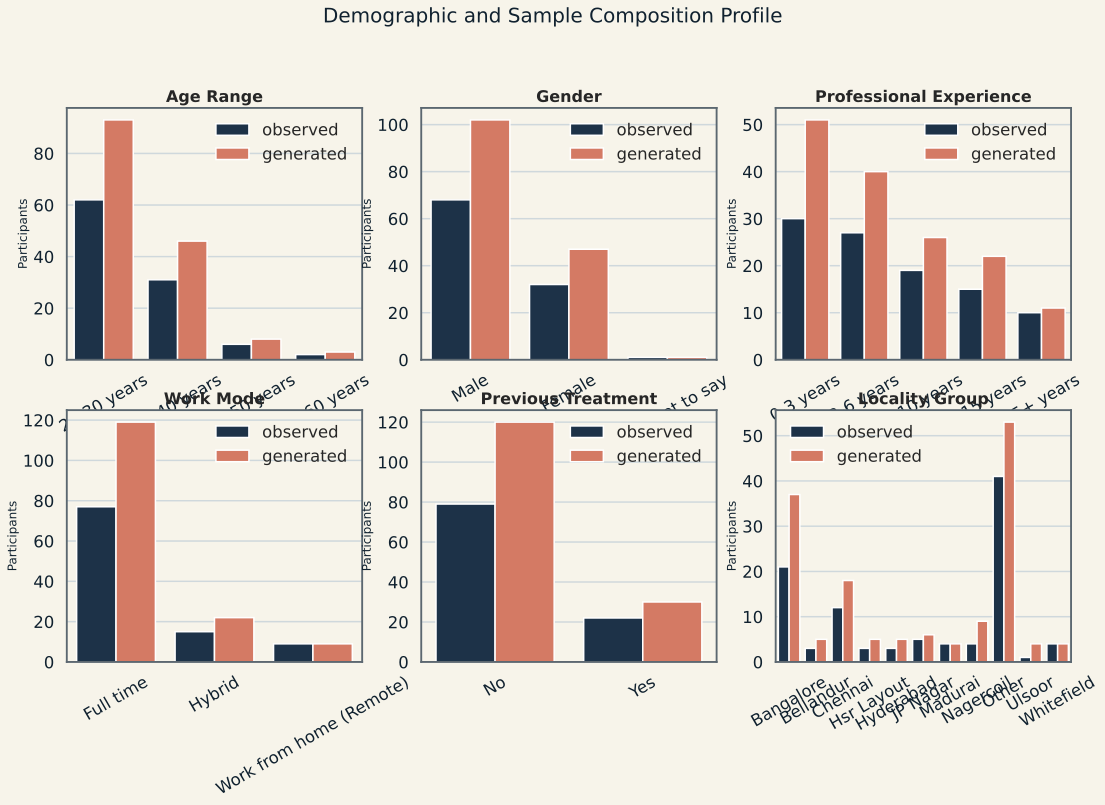

### Trimmed Duration Distribution

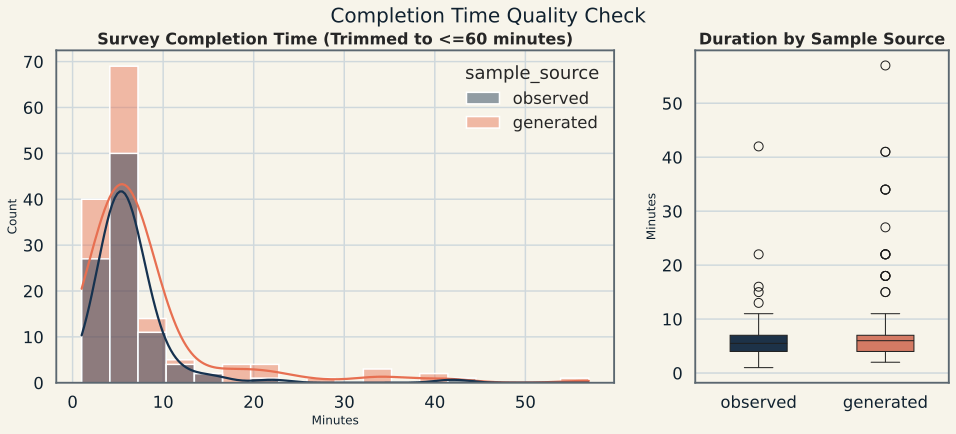

### Knowledge Item Lollipop

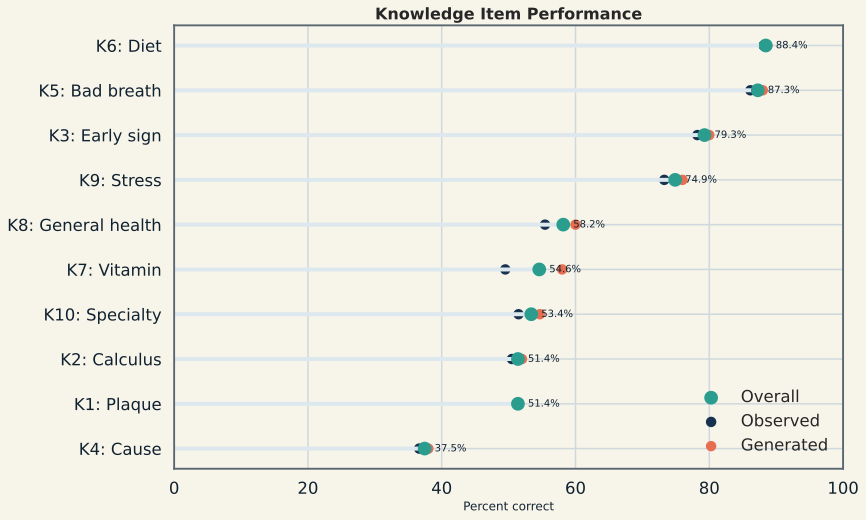

### Attitude Diverging Likert

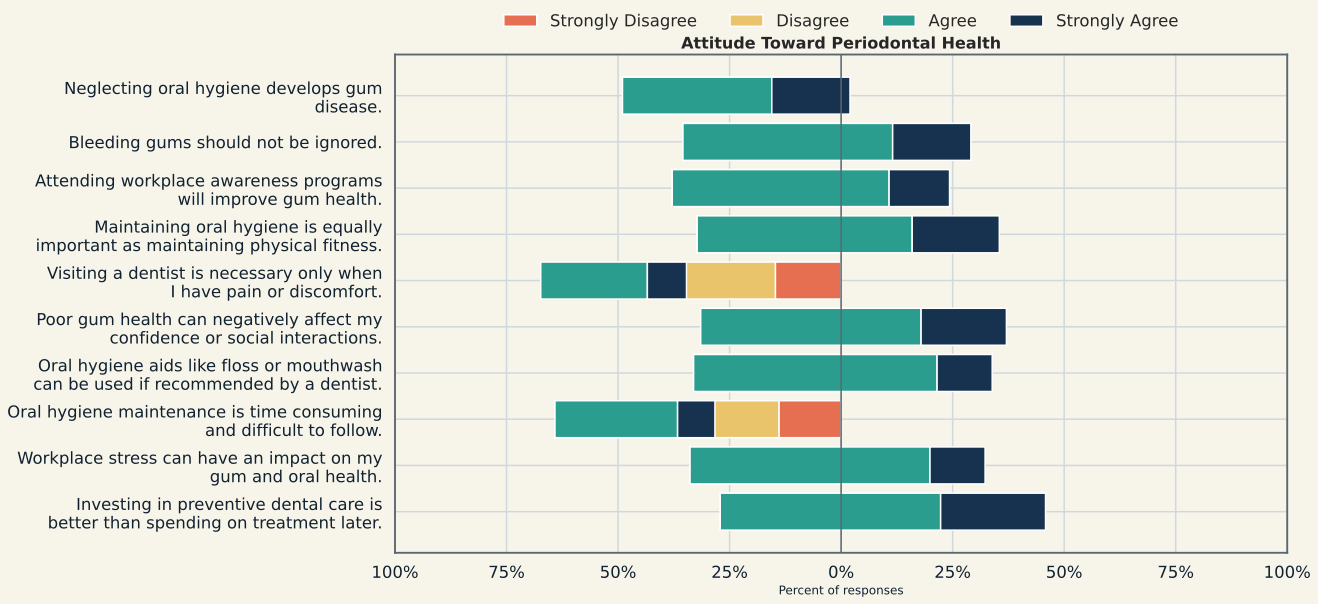

### Practice Response Heatmap

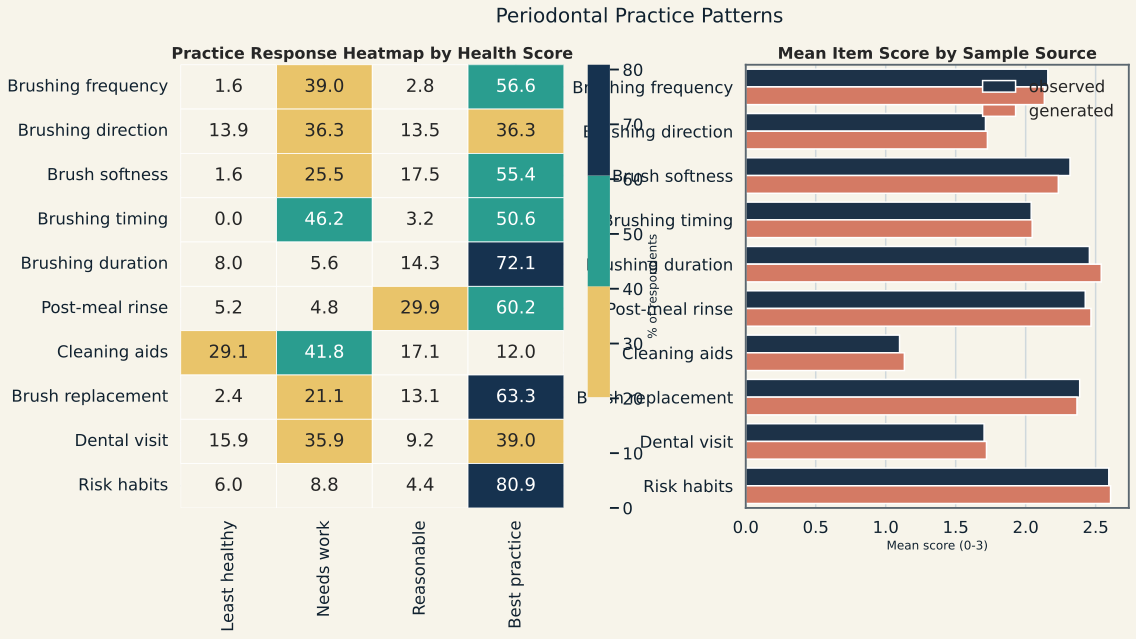

### Composite Score Distributions

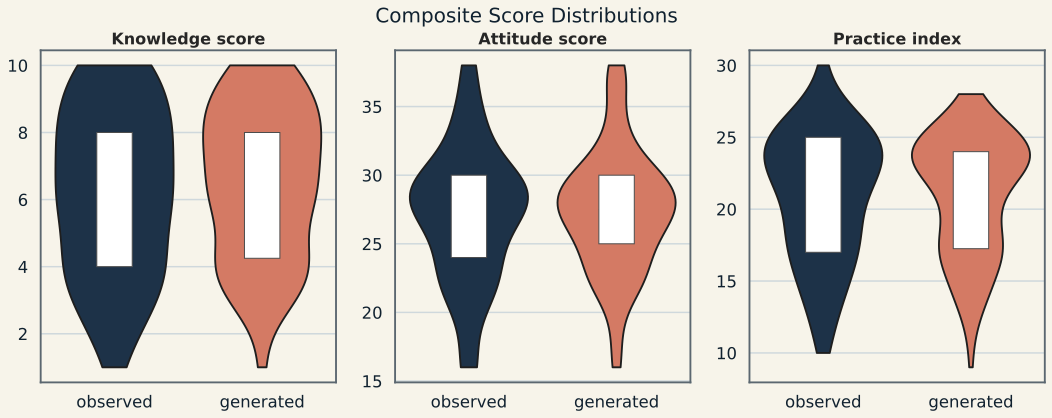

### Kap Correlation Matrix

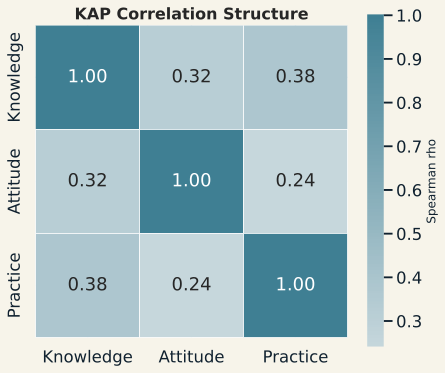

### Observed Vs Generated Comparison

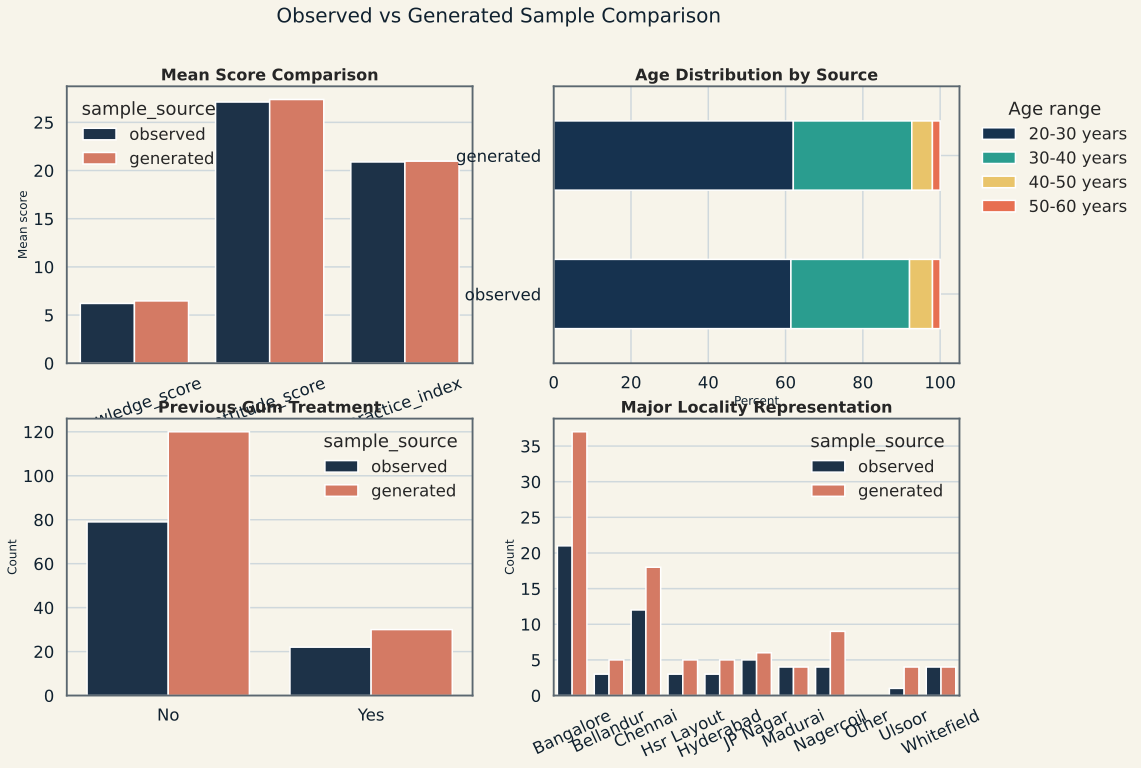

### Regression Effect Forest

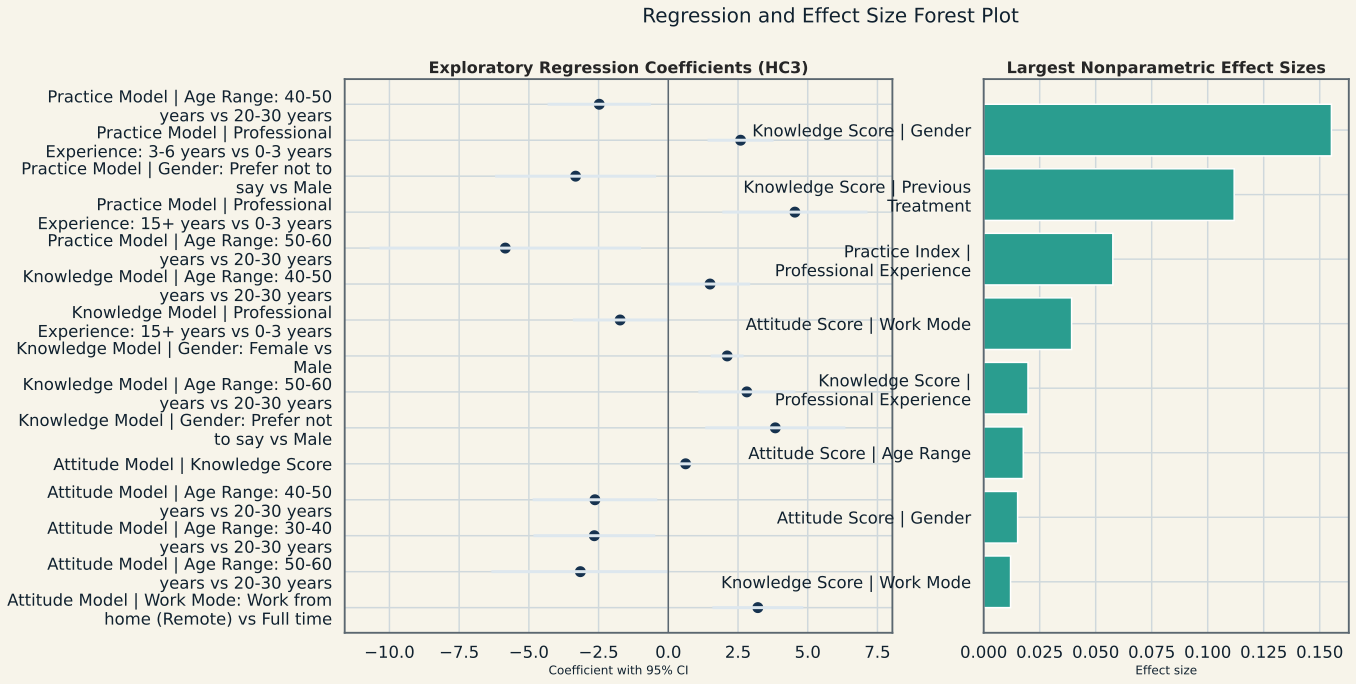

In [6]:
figure_names = [
    'demographic_profile_panel',
    'trimmed_duration_distribution',
    'knowledge_item_lollipop',
    'attitude_diverging_likert',
    'practice_response_heatmap',
    'composite_score_distributions',
    'kap_correlation_matrix',
    'observed_vs_generated_comparison',
    'regression_effect_forest',
]
for name in figure_names:
    display(Markdown(f'### {name.replace("_", " ").title()}'))
    display(SVG(filename=str(FIGURES_DIR / f'{name}.svg')))

## Interpretation and caveats

The key takeaways below are generated after the analysis pipeline writes the final summary tables. Keep the exploratory label attached to any finding that depends on the synthetic augmentation.

In [7]:
display(Markdown((TABLES_DIR / 'insights.md').read_text()))

- Biggest knowledge gaps in the augmented sample were K4 (37.5% correct, What is the primary cause of early gum disease?); K1 (51.4% correct, What is dental plaque?); K2 (51.4% correct, What is dental calculus (tartar)?).
- Knowledge aligned positively with attitude (rho=0.315, 95% CI 0.204 to 0.417) and practice (rho=0.381, 95% CI 0.264 to 0.491).
- Weakest knowledge score groups among categories with n>=10: Age range: 40-50 years (mean 6.07, n=14); Gender: Male (mean 5.73, n=170); Professional experience: 15+ years (mean 5.24, n=21).
- Weakest attitude score groups among categories with n>=10: Age range: 30-40 years (mean 25.97, n=77); Gender: Male (mean 26.71, n=170); Professional experience: 15+ years (mean 26.24, n=21).
- Weakest practice index groups among categories with n>=10: Age range: 30-40 years (mean 20.39, n=77); Gender: Male (mean 20.69, n=170); Professional experience: 10-15 years (mean 20.03, n=37).
- Prior treatment showed yes > no for practice (p=0.103, effect=-0.146).
- Sensitivity analysis found direction changes in 4 comparisons, including knowledge_model | Gender: Other vs Male; knowledge_model | Professional Experience: 10-15 years vs 0-3 years; knowledge_model | Previous Treatment: Yes vs No.
- All augmented-sample inferential findings should be presented as exploratory because 150 appended rows are synthetic augmentations beyond the 101 observed survey responses.
